# 02 MLP

This notebook trains a simple MLP sentiment classifier on the IMDb dataset. It reuses the same cleaning, tokenization, and deterministic splitting utilities as `01_eda.ipynb`.

In [1]:
from __future__ import annotations

import json
import os
import random
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.evaluate import plot_learning_curves
from src.mlp_model import MLPClassifier
from src.preprocess import PAD_ID, UNK_ID, build_vocab, clean_text, create_stratified_splits, tokenize
from src.train import count_parameters


In [2]:
RANDOM_SEED = 42
VOCAB_SIZE = 30000
MAX_LEN = 256
BATCH_SIZE = 128
EPOCHS = 5
FIGURES_DIR = Path("..") / "checkpoints" / "figures"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

device

device(type='mps')

In [3]:
def encode_tokens(tokens: list[str], vocab: dict[str, int], max_len: int) -> list[int]:
    """Convert a token list into a fixed-length vector of token ids."""
    encoded = [vocab.get(token, UNK_ID) for token in tokens[:max_len]]
    if len(encoded) < max_len:
        encoded.extend([PAD_ID] * (max_len - len(encoded)))
    return encoded


def frame_to_tensors(df: pd.DataFrame, vocab: dict[str, int], max_len: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Encode one split DataFrame into input-id and label tensors."""
    encoded = [encode_tokens(tokens, vocab, max_len) for tokens in df["tokens"]]
    input_ids = torch.tensor(encoded, dtype=torch.long)
    labels = torch.tensor(df["label"].tolist(), dtype=torch.long)
    return input_ids, labels


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> dict[str, float]:
    """Evaluate a classifier and return held-out loss and binary metrics."""
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            logits = model(input_ids)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        zero_division=0,
    )
    return {
        "loss": total_loss / max(total_items, 1),
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int = EPOCHS,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-5,
    checkpoint_path: Path | None = None,
) -> pd.DataFrame:
    """Train an MLP and return the epoch-by-epoch training history."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = []
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_items = 0

        for input_ids, labels in train_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += int((logits.argmax(dim=1) == labels).sum().item())
            total_items += batch_size

        val_metrics = evaluate_model(model, val_loader, criterion, device)
        history.append(
            {
                "epoch": epoch,
                "train_loss": total_loss / max(total_items, 1),
                "train_accuracy": total_correct / max(total_items, 1),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
            }
        )

        if checkpoint_path is not None and val_metrics["accuracy"] > best_val_acc:
            best_val_acc = val_metrics["accuracy"]
            checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)

    if checkpoint_path is not None and checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    return pd.DataFrame(history)


In [4]:
splits = create_stratified_splits(seed=RANDOM_SEED)
split_frames = {name: split.to_pandas() for name, split in splits.items()}

for df in split_frames.values():
    df["clean_text"] = df["text"].map(clean_text)
    df["tokens"] = df["clean_text"].map(tokenize)

vocab = build_vocab(split_frames["train"]["tokens"].tolist(), max_vocab_size=VOCAB_SIZE)

train_inputs, train_labels = frame_to_tensors(split_frames["train"], vocab, MAX_LEN)
val_inputs, val_labels = frame_to_tensors(split_frames["validation"], vocab, MAX_LEN)
test_inputs, test_labels = frame_to_tensors(split_frames["test"], vocab, MAX_LEN)

train_loader = DataLoader(TensorDataset(train_inputs, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_inputs, val_labels), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(test_inputs, test_labels), batch_size=BATCH_SIZE, shuffle=False)

pd.DataFrame(
    [
        {"split": "train", "size": len(train_labels)},
        {"split": "validation", "size": len(val_labels)},
        {"split": "test", "size": len(test_labels)},
        {"split": "vocab", "size": len(vocab)},
    ]
)

,split,size
0,train,35000
1,validation,5000
2,test,10000
3,vocab,30000


In [5]:
DEPTH_CONFIGS = {
    "depth_1": [320],
    "depth_2": [256, 128],
    "depth_3": [256, 128, 64],
}
EXPORT_PATH = Path("..") / "checkpoints" / "mlp_best_result.json"


def make_model(embed_dim: int, hidden_dims: list[int], dropout: float) -> MLPClassifier:
    """Construct an MLP classifier for one experiment configuration."""
    return MLPClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dims=hidden_dims,
        num_classes=2,
        dropout=dropout,
    ).to(device)


def run_experiment(
    embed_dim: int,
    hidden_dims: list[int],
    dropout: float,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-5,
    epochs: int = EPOCHS,
    run_name: str = "mlp_run",
) -> dict[str, object]:
    """Train one controlled MLP run and collect metrics, artifacts, and metadata."""
    model = make_model(embed_dim=embed_dim, hidden_dims=hidden_dims, dropout=dropout)
    checkpoint_path = Path("..") / "checkpoints" / f"{run_name}.pt"
    start_time = time.time()
    history_df = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        checkpoint_path=checkpoint_path,
    )
    training_time_sec = time.time() - start_time
    test_metrics = evaluate_model(model, test_loader, nn.CrossEntropyLoss(), device)
    curve_figure = plot_learning_curves(history_df, title=run_name)
    figure_path = FIGURES_DIR / f"{run_name}_learning_curves.png"
    curve_figure.savefig(figure_path, dpi=200, bbox_inches="tight")
    return {
        "run": run_name,
        "embed_dim": embed_dim,
        "hidden_dims": hidden_dims,
        "dropout": dropout,
        "parameter_count": count_parameters(model),
        "checkpoint": str(checkpoint_path),
        "figure_path": str(figure_path),
        "history_df": history_df,
        "curve_figure": curve_figure,
        "training_time_sec": training_time_sec,
        "time_per_epoch_sec": training_time_sec / max(epochs, 1),
        **test_metrics,
    }


depth_parameter_table = pd.DataFrame(
    [
        {
            "run": run_name,
            "hidden_dims": hidden_dims,
            "parameter_count": count_parameters(make_model(embed_dim=128, hidden_dims=hidden_dims, dropout=0.3)),
        }
        for run_name, hidden_dims in DEPTH_CONFIGS.items()
    ]
)
display(depth_parameter_table)

sample_model = make_model(embed_dim=128, hidden_dims=DEPTH_CONFIGS["depth_2"], dropout=0.3)
sample_model


,run,hidden_dims,parameter_count
0,depth_1,[320],3881922
1,depth_2,"[256, 128]",3906178
2,depth_3,"[256, 128, 64]",3914306


MLPClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [6]:
run_depth = True
run_emb = True
run_drop = True
run_baseline = True

,run,embed_dim,hidden_dims,dropout,parameter_count,accuracy,precision,recall,f1,checkpoint,figure_path
0,depth_3,128,"[256, 128, 64]",0.3,3914306,0.8800,0.861905,0.9050,0.882927,../checkpoints/depth_3.pt,../checkpoints/figures/depth_3_learning_curves...
1,emb_256,256,"[256, 128, 64]",0.3,7787074,0.8800,0.873721,0.8884,0.881000,../checkpoints/emb_256.pt,../checkpoints/figures/emb_256_learning_curves...
2,depth_1,128,[320],0.3,3881922,0.8791,0.878117,0.8804,0.879257,../checkpoints/depth_1.pt,../checkpoints/figures/depth_1_learning_curves...
3,depth_2,128,"[256, 128]",0.3,3906178,0.8790,0.879000,0.8790,0.879000,../checkpoints/depth_2.pt,../checkpoints/figures/depth_2_learning_curves...
4,mlp_baseline,128,"[256, 128]",0.3,3906178,0.8780,0.876194,0.8804,0.878292,../checkpoints/mlp_baseline.pt,../checkpoints/figures/mlp_baseline_learning_c...
5,drop_0.2,128,"[256, 128, 64]",0.2,3914306,0.8779,0.879799,0.8754,0.877594,../checkpoints/drop_0.2.pt,../checkpoints/figures/drop_0.2_learning_curve...
6,drop_0.5,128,"[256, 128, 64]",0.5,3914306,0.8773,0.862301,0.8980,0.879788,../checkpoints/drop_0.5.pt,../checkpoints/figures/drop_0.5_learning_curve...
7,emb_64,64,"[256, 128, 64]",0.3,1977922,0.8771,0.894044,0.8556,0.874400,../checkpoints/emb_64.pt,../checkpoints/figures/emb_64_learning_curves.png
8,drop_0.3,128,"[256, 128, 64]",0.3,3914306,0.8769,0.882484,0.8696,0.875995,../checkpoints/drop_0.3.pt,../checkpoints/figures/drop_0.3_learning_curve...
9,emb_128,128,"[256, 128, 64]",0.3,3914306,0.8763,0.857224,0.9030,0.879517,../checkpoints/emb_128.pt,../checkpoints/figures/emb_128_learning_curves...


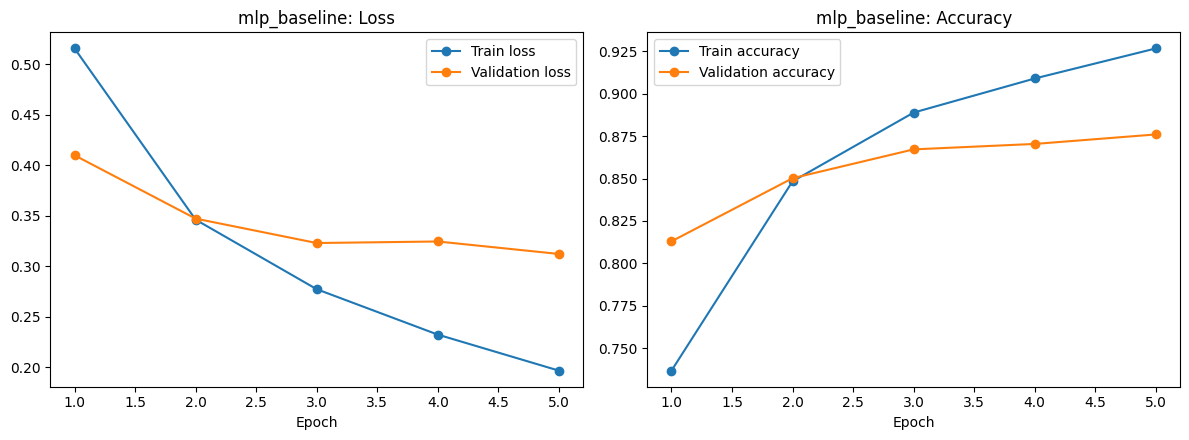

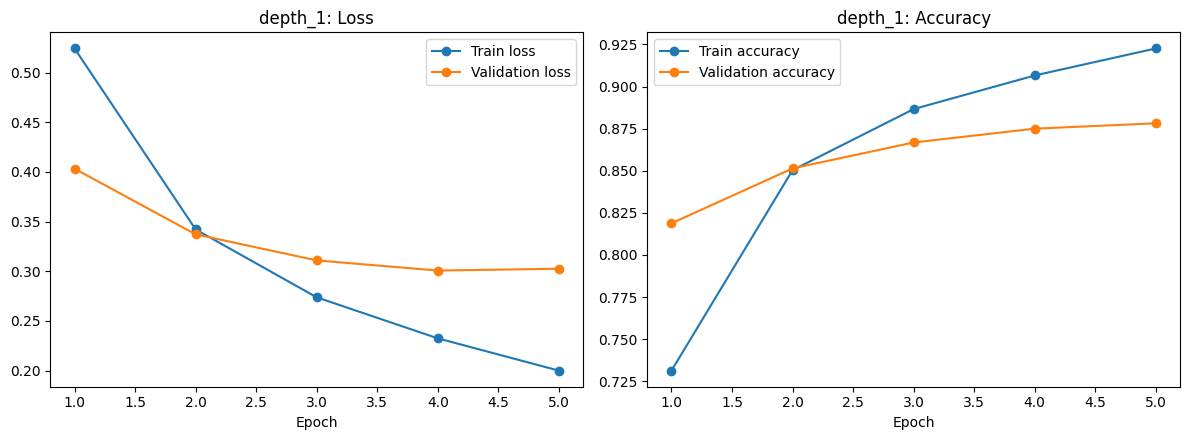

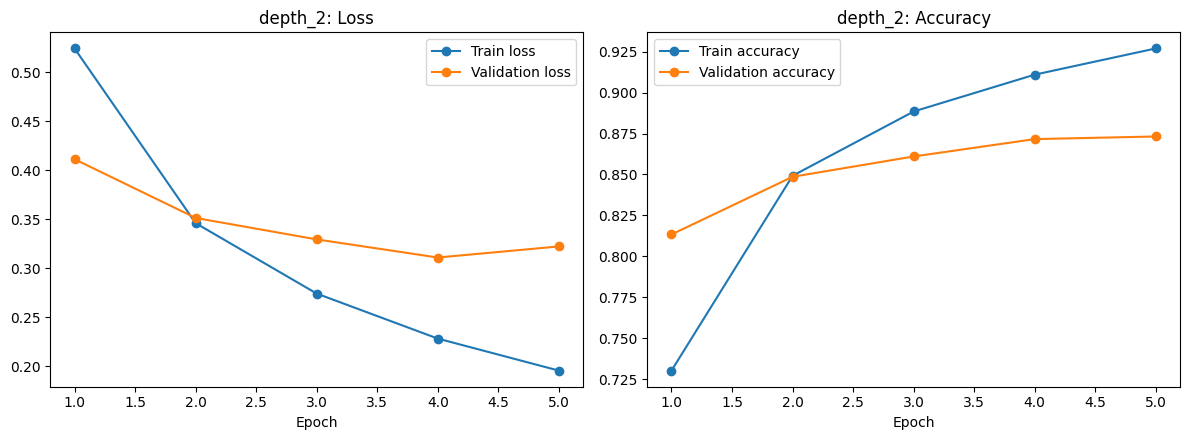

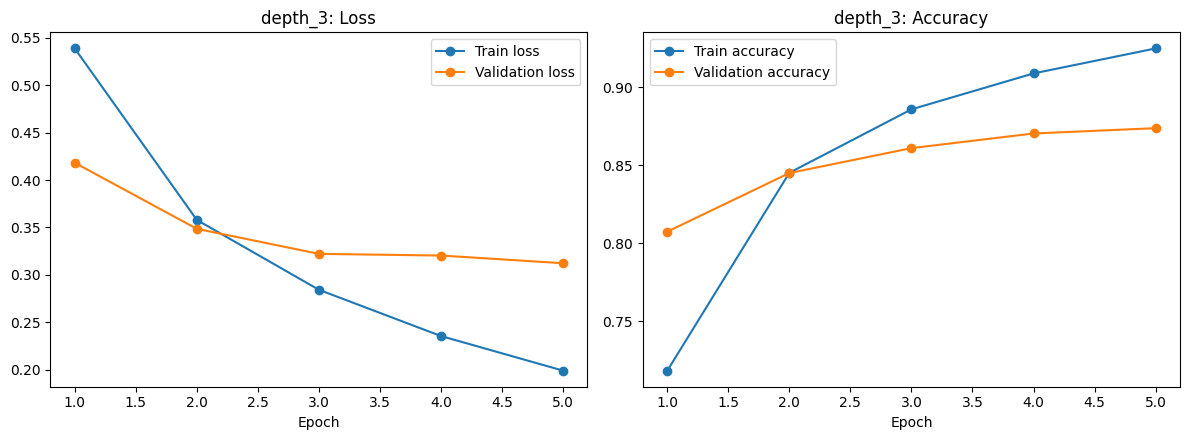

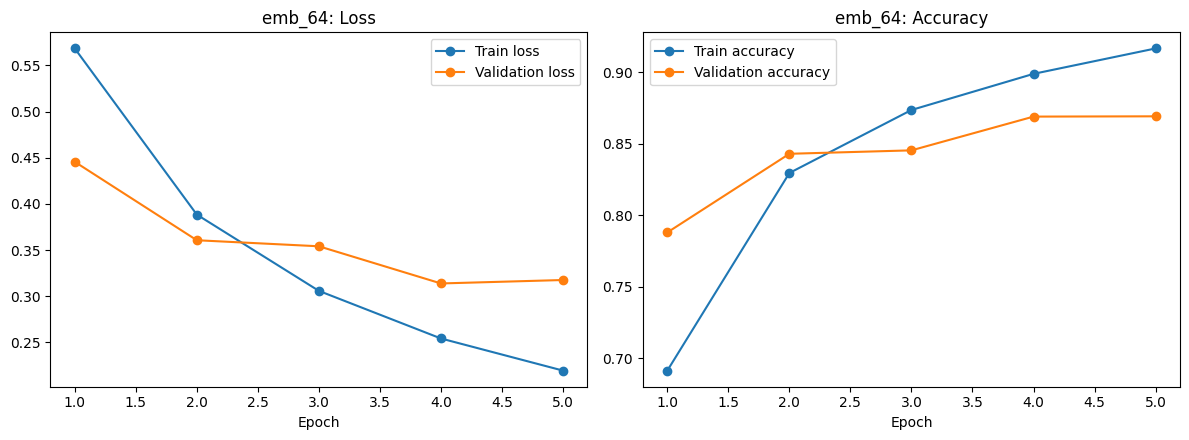

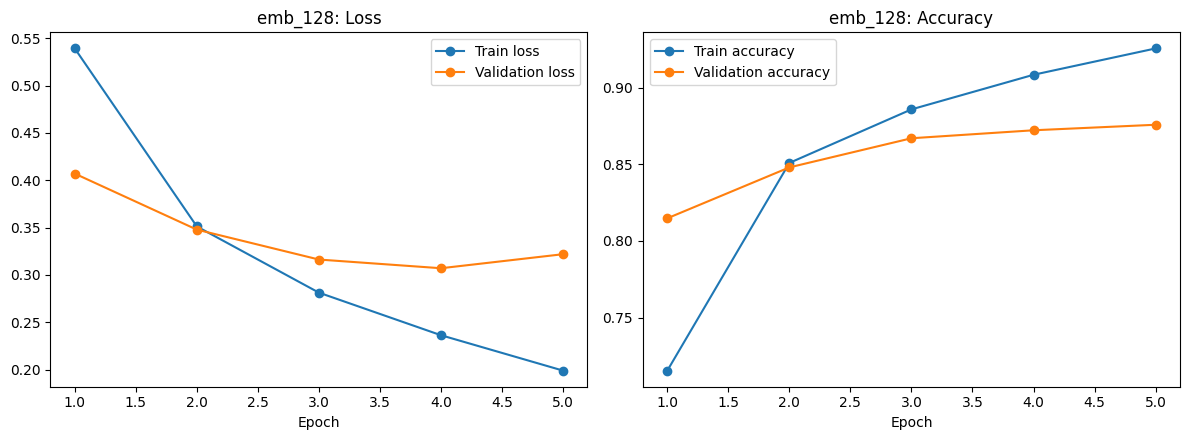

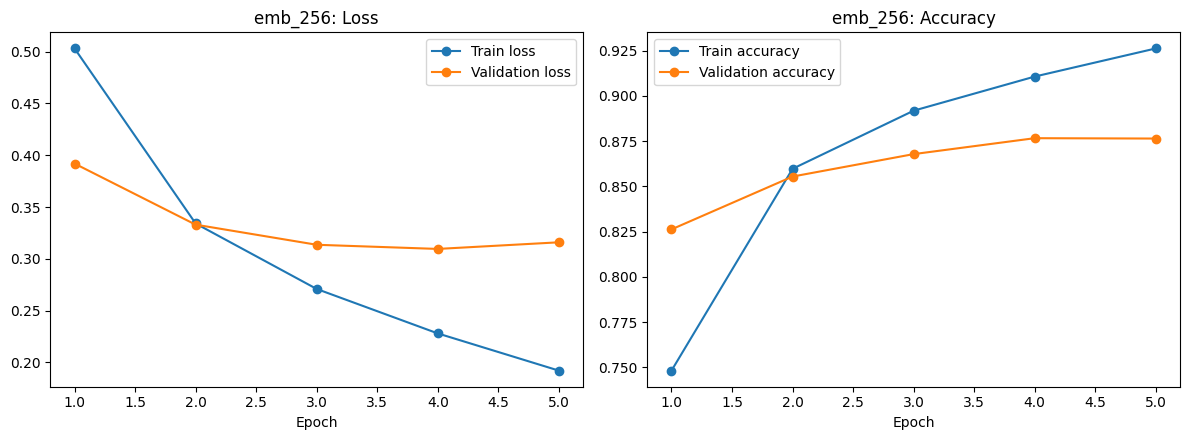

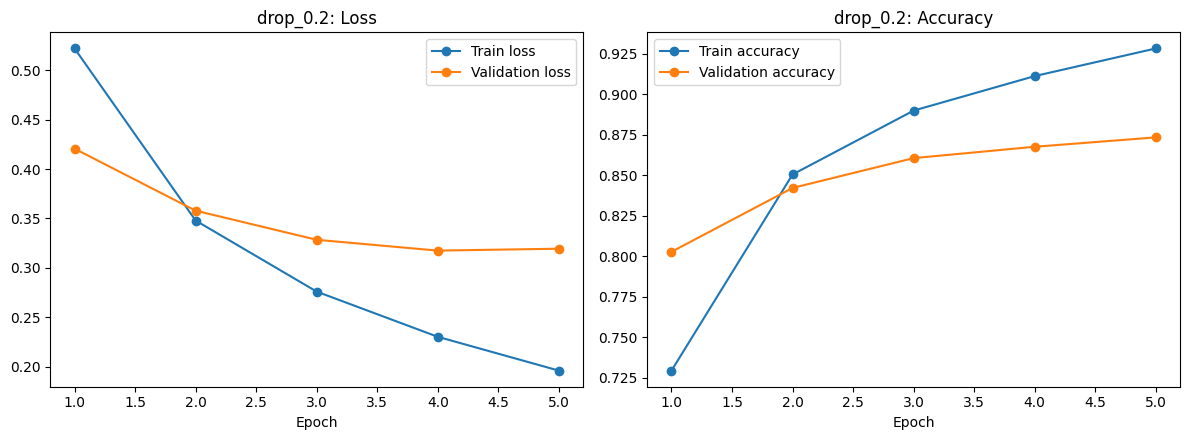

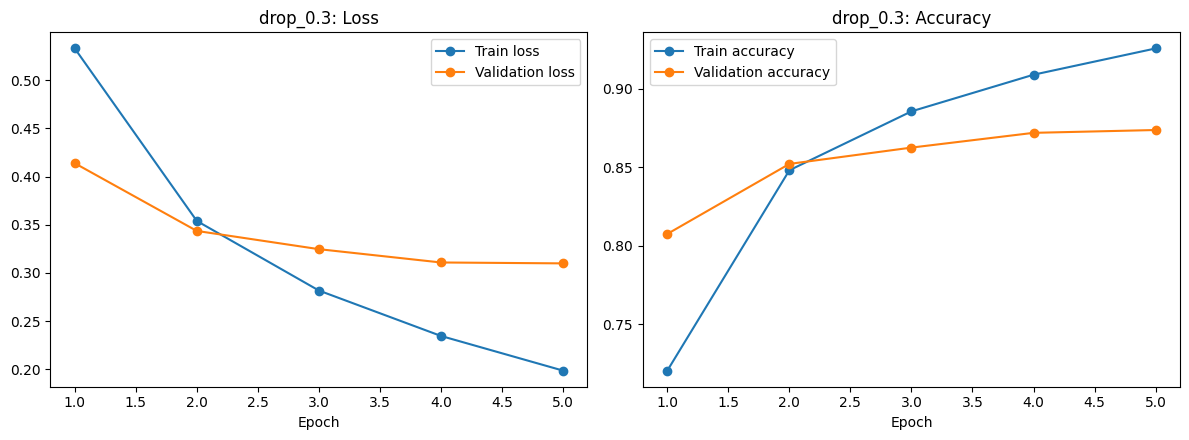

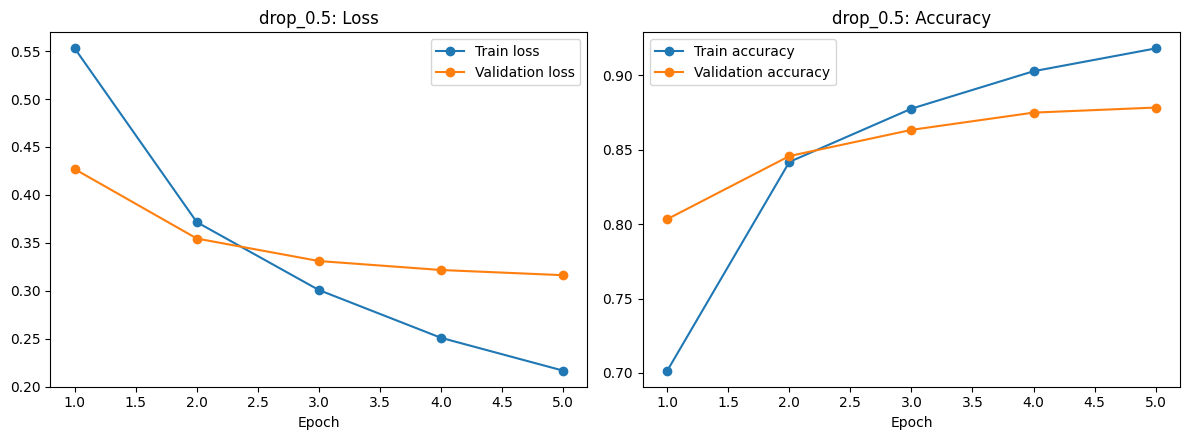

In [7]:
results = []

if run_baseline:
    baseline_result = run_experiment(
        embed_dim=128,
        hidden_dims=DEPTH_CONFIGS["depth_2"],
        dropout=0.3,
        run_name="mlp_baseline",
    )
    results.append(baseline_result)

if run_depth:
    for run_name, hidden_dims in DEPTH_CONFIGS.items():
        results.append(run_experiment(128, hidden_dims, 0.3, run_name=run_name))

best_depth_result = None
if run_depth:
    depth_results = [row for row in results if row["run"] in DEPTH_CONFIGS]
    if depth_results:
        best_depth_result = max(depth_results, key=lambda row: row["accuracy"])
        best_depth_hidden_dims = best_depth_result["hidden_dims"]
    else:
        best_depth_hidden_dims = DEPTH_CONFIGS["depth_2"]
else:
    best_depth_hidden_dims = DEPTH_CONFIGS["depth_2"]

if run_emb:
    for emb in [64, 128, 256]:
        results.append(run_experiment(emb, best_depth_hidden_dims, 0.3, run_name=f"emb_{emb}"))

if run_drop:
    for drop in [0.2, 0.3, 0.5]:
        results.append(run_experiment(128, best_depth_hidden_dims, drop, run_name=f"drop_{drop}"))

summary_df = pd.DataFrame(
    [
        {
            "run": row["run"],
            "embed_dim": row["embed_dim"],
            "hidden_dims": row["hidden_dims"],
            "dropout": row["dropout"],
            "parameter_count": row["parameter_count"],
            "accuracy": row["accuracy"],
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "checkpoint": row["checkpoint"],
            "figure_path": row["figure_path"],
        }
        for row in results
    ]
).sort_values(by=["accuracy", "f1", "precision", "recall"], ascending=False).reset_index(drop=True)
summary_df


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.538617,0.718200,0.418136,0.8074
1,2,0.357931,0.845171,0.348574,0.8450
2,3,0.284357,0.885886,0.322200,0.8610
3,4,0.235637,0.908943,0.320432,0.8704
4,5,0.199193,0.924971,0.312330,0.8738


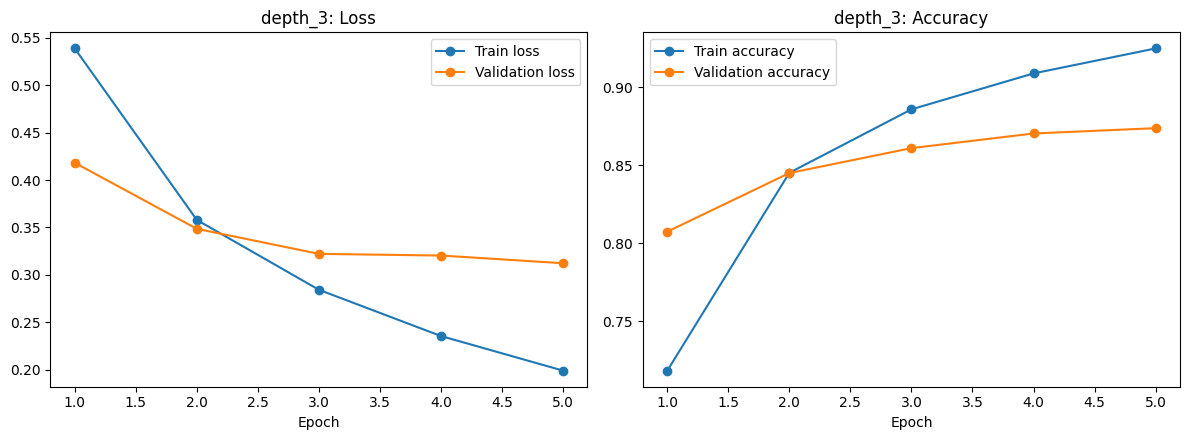

In [8]:
if results:
    best_result = max(results, key=lambda row: row["accuracy"])
    source_path = Path(best_result["checkpoint"])
    target_path = Path("..") / "checkpoints" / "mlp_best.pt"
    target_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(source_path, target_path)
    mlp_best_result_export = {
        "model": "MLP (best configuration)",
        "variant": "mlp",
        "accuracy": best_result["accuracy"],
        "precision": best_result["precision"],
        "recall": best_result["recall"],
        "f1": best_result["f1"],
        "time_per_epoch_sec": best_result["time_per_epoch_sec"],
        "checkpoint_path": str(target_path),
        "figure_path": best_result["figure_path"],
        "run": best_result["run"],
        "embed_dim": best_result["embed_dim"],
        "hidden_dims": best_result["hidden_dims"],
        "dropout": best_result["dropout"],
        "parameter_count": best_result["parameter_count"],
    }
    EXPORT_PATH.write_text(json.dumps(mlp_best_result_export, indent=2))
    display(best_result["history_df"])
    display(best_result["curve_figure"])
    pd.DataFrame([mlp_best_result_export])
else:
    print("No experiments were run. Toggle one of the run_* flags to True.")
